## Is it a bird?

In [1]:
import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [2]:
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install fastai fastcore fastdownload requests

The basic steps we'll take are:

1. Use Pexels to search for images of "bird photos"
1. Use Pexels to search for images of "forest photos"
1. Fine-tune a pretrained neural network to recognise these two groups
1. Try running this model on a picture of a bird and see if it works.

## Step 1: Download images of birds and non-birds

In [4]:
from fastcore.all import *
from fastdownload import download_url
from fastai.vision.all import *
from pathlib import Path
import requests, time


# Paste your Pexels API key here
PEXELS_API_KEY = "YOUR_PEXELS_API_KEY"


def search_images_pexels(query, max_images=50):
    headers = {
        "Authorization": PEXELS_API_KEY
    }

    url = "https://api.pexels.com/v1/search"

    params = {
        "query": query,
        "per_page": max_images
    }

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()

    results = response.json()["photos"]

    # Return list of image URLs
    return L([img["src"]["large"] for img in results])


# Example single-image download test
urls = search_images_pexels("bird", max_images=1)

dest = "bird.jpg"
download_url(urls[0], dest, show_progress=False)

Image.open(dest).to_thumb(256,256)


# Another test image
download_url(
    search_images_pexels("forest", max_images=1)[0],
    "forest.jpg",
    show_progress=False
)

Image.open("forest.jpg").to_thumb(256,256)


# Dataset creation (same structure as your original fastai workflow)
searches = "forest", "bird"
path = Path("bird_or_not")

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)

    print(f"Downloading images for: {o}")

    urls = search_images_pexels(f"{o} photo", max_images=50)

    download_images(dest, urls=urls)

    time.sleep(3)

    resize_images(path/o, max_size=400, dest=path/o)


print("Dataset ready ✅")

Dataset ready ✅


## Step 2: Train our model

Some photos might not download correctly which could cause our model training to fail, so we'll remove them:

In [5]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

To train a model, we'll need `DataLoaders`, which is an object that contains a *training set* (the images used to create a model) and a *validation set* (the images used to check the accuracy of a model -- not used during training). In `fastai` we can create that easily using a `DataBlock`, and view sample images from it:

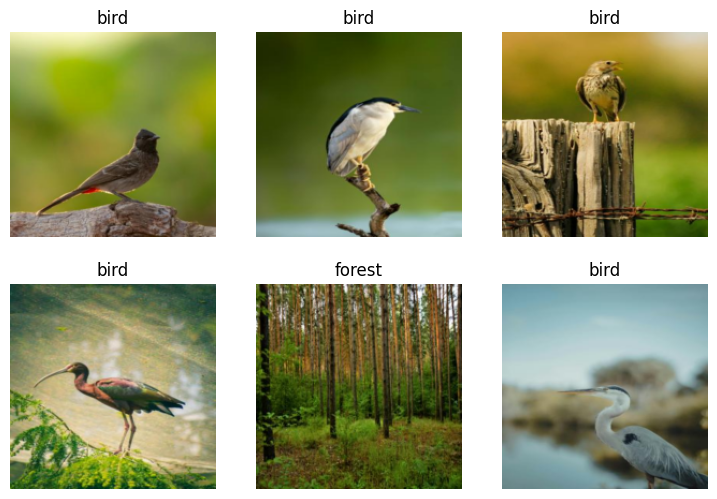

In [6]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

Now we're ready to train our model. The fastest widely used computer vision model is `resnet18`. Using fast ai - finetune

In [7]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 111MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.187464,1.623530,0.500000,00:12


epoch,train_loss,valid_loss,error_rate,time
0,0.432557,0.604122,0.100000,00:14
1,0.256761,0.294527,0.050000,00:14
2,0.197586,0.195273,0.050000,00:18


Generally when I run this I see 100% accuracy on the validation set (although it might vary a bit from run to run).

"Fine-tuning" a model means that we're starting with a model someone else has trained using some other dataset (called the *pretrained model*), and adjusting the weights a little bit so that the model learns to recognise your particular dataset. In this case, the pretrained model was trained to recognise photos in *imagenet*, and widely-used computer vision dataset with images covering 1000 categories)

## Step 3: Use the Model

Let's see what our model thinks about that bird we downloaded at the start:

In [10]:
is_bird,_,probs = learn.predict(PILImage.create('bird.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a bird: {probs[0]:.4f}")

This is a: bird.
Probability it's a bird: 0.9996


Good job, resnet18. :)


checking Probability of a forest

In [12]:
is_bird,_,probs = learn.predict(PILImage.create('forest.jpg'))
print(f"This is a: {is_bird}.")
print(f"Probability it's a {is_bird} is: {probs[learn.dls.vocab.o2i[is_bird]]:.4f}")

This is a: forest.
Probability it's a forest is: 0.9954
